# Student Name: Isaiah Andres
# Student Number: C00286361

## Introduction:
In this notebook, a K Nearest Neighbours (KNN) model will be used in order to identify what kind category of projects from Kickstarter are likely to be successful based on their category, the amount pledged, the number of backers and the country they start in from the Kickstarter Projects dataset (Link: https://www.kaggle.com/datasets/kemical/kickstarter-projects), and see how well the model will fare.

# Importing and Preprocessing Data
The cell below shows the necessary imports made for this portfolio as well as some preprocessing, including the removal of certain project states such as live, suspended and canceled. I decided not to train the model on the amount of money pledged as it seemed to have an unusually high acurracy at 98% if included so it will only used as the x axis when plotting the points. The quality of predictions made by the model may also suffer from the large range of donation goals for a project, so it's necessary to normalise the data so a MinMaxScaler is used to scale the data from a range of 0 to 1 for the plotted points as the actual data points that the model will be trained will be scaled in the future. The dataset is also split into training and testing sets including a plot of each set as the amount pledged is not included.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from math import sqrt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import numpy as np

kickstarter_dataset = pd.read_csv('ks-projects-201801.csv')
kickstarter_dataset = kickstarter_dataset.dropna()
kickstarter_dataset = kickstarter_dataset[(kickstarter_dataset.state != "live") & (kickstarter_dataset.state != "suspended") & (kickstarter_dataset.state != "canceled")]

coordinates = ["usd_pledged_real","usd_goal_real"] 
X_plot = kickstarter_dataset[coordinates].copy()

categorical_features = ["main_category", "country"]
numeric_features = ["backers", "usd_goal_real"]

X = kickstarter_dataset[categorical_features + numeric_features]
y = kickstarter_dataset["state"]

X_train, X_test, y_train, y_test, X_plot_train, X_plot_test = train_test_split(X, y, X_plot, test_size=0.3, random_state=1)

scaler = MinMaxScaler()
X_plot_train = scaler.fit_transform(X_plot_train)
X_plot_test = scaler.transform(X_plot_test)

The values for the state of each project is categorical so it's necessary to convert them into a label using a LabelEncoder. The numeric and categorical features were seperated in the last cell, a ColumnTransformer is used to apply different preprocessing techniques to the numeric and categorical features. The numeric values have been scaled to improve the quality of the model's predictions, and since KNN requires numerical values, one hot encoding has been applied to the categorical features. One hot encoding however adds extra dimensionality by creating new columns for different categories, affecting the quality of the KNN model again. The use of PCA is therefore used to decrease the dimensionality of the data, in this case the number of principal components to keep is the number of componenents that will give a variance of 95%. 

In [2]:
print(kickstarter_dataset["state"].unique())

le = LabelEncoder()

y_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

pca = PCA(n_components=0.95)
X_pca_training = pca.fit_transform(X_train_processed)
X_pca_testing = pca.transform(X_test_processed)

['failed' 'successful']


# Training The Model
The KNN model is now trained on the preprocessed data. The categories and their codes are also retrieved in order to create a legend of the different categories and a green or a red circle is added to the points depending on if they're successful or a failure respectively.

In [4]:
param_grid = {'n_neighbors': range(1, 10)}
knn_model = KNeighborsClassifier()
grid_search = GridSearchCV(knn_model, param_grid, cv=5)
grid_search.fit(X_pca_training, y_encoded)
optimal_k = grid_search.best_params_['n_neighbors']
print(f"The optimal K value is: {optimal_k}")

The optimal K value is: 9


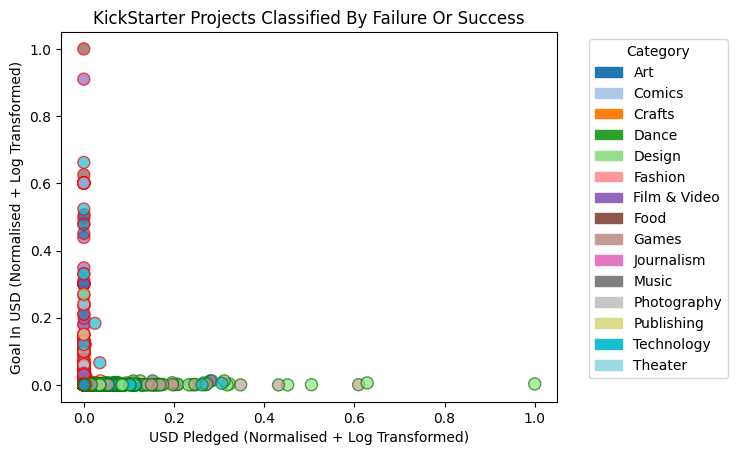

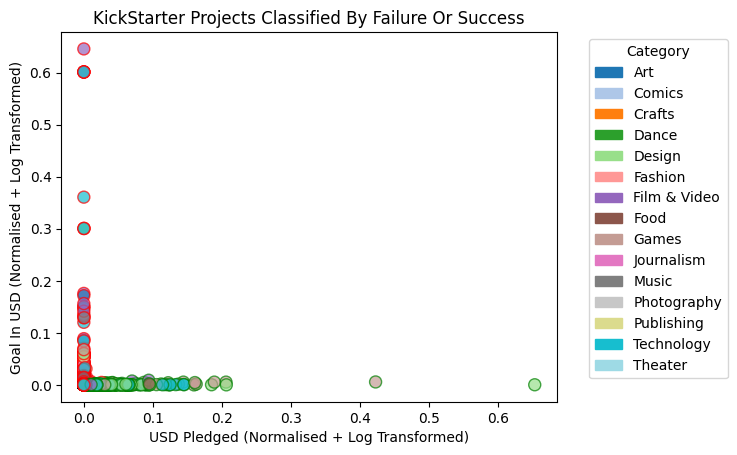

              precision    recall  f1-score   support

      failed       0.93      0.91      0.92     59133
  successful       0.87      0.90      0.88     40306

    accuracy                           0.90     99439
   macro avg       0.90      0.90      0.90     99439
weighted avg       0.91      0.90      0.90     99439



In [5]:
knn_model = KNeighborsClassifier(n_neighbors=9)

knn_model.fit(X_pca_training, y_encoded)
train_preds = knn_model.predict(X_pca_training)

categories = X_train["main_category"].astype("category").cat.categories
category_codes = X_train["main_category"].astype("category").cat.codes

cmap = plt.get_cmap("tab20", len(categories))

edge_colors = ["green" if y == 1 else "red" for y in y_encoded]

plt.scatter(
    X_plot_train[:, 0],
    X_plot_train[:, 1],
    c=category_codes,
    cmap=cmap,
    edgecolors=edge_colors,
    linewidth=1,
    s=75,
    alpha=0.7
)

patches = [mpatches.Patch(color=cmap(i), label=cat) for i, cat in enumerate(categories)]
plt.legend(handles=patches, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("KickStarter Projects Classified By Failure Or Success")
plt.xlabel('USD Pledged (Normalised + Log Transformed)')
plt.ylabel('Goal In USD (Normalised + Log Transformed)')
plt.show()

test_preds = knn_model.predict(X_pca_testing)

categories = X_test["main_category"].astype("category").cat.categories
category_codes = X_test["main_category"].astype("category").cat.codes

edge_colors = ["green" if y == 1 else "red" for y in y_test_encoded]

plt.scatter(
    X_plot_test[:, 0],
    X_plot_test[:, 1],
    c=category_codes,
    cmap=cmap,
    edgecolors=edge_colors,
    linewidth=1,
    s=75,
    alpha=0.7
)

patches = [mpatches.Patch(color=cmap(i), label=cat) for i, cat in enumerate(categories)]
plt.legend(handles=patches, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("KickStarter Projects Classified By Failure Or Success")
plt.xlabel('USD Pledged (Normalised + Log Transformed)')
plt.ylabel('Goal In USD (Normalised + Log Transformed)')
plt.show()

report = classification_report(y_test_encoded, test_preds, labels=range(len(le.classes_)), target_names=le.classes_, zero_division=0) #Getting Classification Report
print(report)

# Model Performance
The model appears to be quite accurate in predicting both types failures and successes, with slightly better performance for predicting failed projects. However the points appear to cluster in the bottom left of the graph, this is likely due to the fact that some projects may be looking for hundreds of thousands in donations while others may be looking for a few thousand. Seemingly the most successful categories of projects are design and games and also don't seem to ask for as much as many other projects, and many projects that appear to ask for massive amounts of donations in comparison to the rest of the other projects naturally seem to fail as massive donation goals seem to be unfulfilled.

# Using Other Data
Within the dataset aer alternative values for the amount of money pledged as well as the goal. The first model used conversions for all the money pledged as well as the goals using Fixer API (https://fixer.io/). The model below will be trained on the conversions made by Kickstarter for the goal set and amount pledged in USD in order to try and see if a difference is made.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from math import sqrt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
import numpy as np

kickstarter_dataset = pd.read_csv('ks-projects-201801.csv')
kickstarter_dataset = kickstarter_dataset.dropna()
kickstarter_dataset = kickstarter_dataset[(kickstarter_dataset.state != "live") & (kickstarter_dataset.state != "suspended") & (kickstarter_dataset.state != "canceled")]

coordinates = ["usd pledged","goal"] 
X_plot = kickstarter_dataset[coordinates].copy()

categorical_features = ["main_category", "country"]
numeric_features = ["backers", "goal"]

X = kickstarter_dataset[categorical_features + numeric_features]
y = kickstarter_dataset["state"]

X_train, X_test, y_train, y_test, X_plot_train, X_plot_test = train_test_split(X, y, X_plot, test_size=0.3, random_state=1)

scaler = MinMaxScaler()
X_plot_train = scaler.fit_transform(X_plot_train)
X_plot_test = scaler.transform(X_plot_test)

In [7]:
print(kickstarter_dataset["state"].unique())

le = LabelEncoder()

y_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

pca = PCA(n_components=0.95)
X_pca_training = pca.fit_transform(X_train_processed)
X_pca_testing = pca.transform(X_test_processed)

['failed' 'successful']


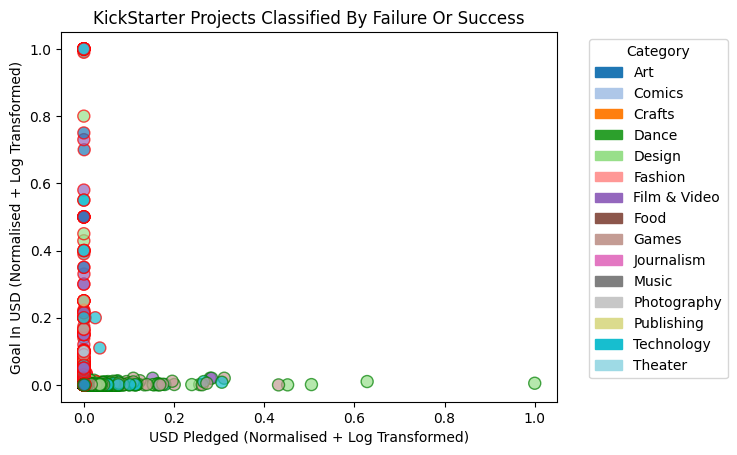

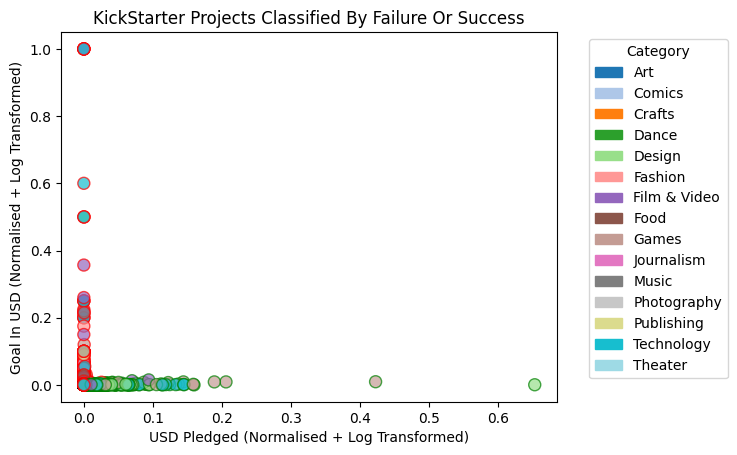

              precision    recall  f1-score   support

      failed       0.93      0.94      0.93     59133
  successful       0.91      0.89      0.90     40306

    accuracy                           0.92     99439
   macro avg       0.92      0.91      0.92     99439
weighted avg       0.92      0.92      0.92     99439



In [8]:
knn_model = KNeighborsClassifier(n_neighbors=10)

knn_model.fit(X_pca_training, y_encoded)
train_preds = knn_model.predict(X_pca_training)

categories = X_train["main_category"].astype("category").cat.categories
category_codes = X_train["main_category"].astype("category").cat.codes

cmap = plt.get_cmap("tab20", len(categories))

edge_colors = ["green" if y == 1 else "red" for y in y_encoded]

plt.scatter(
    X_plot_train[:, 0],
    X_plot_train[:, 1],
    c=category_codes,
    cmap=cmap,
    edgecolors=edge_colors,
    linewidth=1,
    s=75,
    alpha=0.7
)

patches = [mpatches.Patch(color=cmap(i), label=cat) for i, cat in enumerate(categories)]
plt.legend(handles=patches, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("KickStarter Projects Classified By Failure Or Success")
plt.xlabel('USD Pledged (Normalised + Log Transformed)')
plt.ylabel('Goal In USD (Normalised + Log Transformed)')
plt.show()

test_preds = knn_model.predict(X_pca_testing)

categories = X_test["main_category"].astype("category").cat.categories
category_codes = X_test["main_category"].astype("category").cat.codes

edge_colors = ["green" if y == 1 else "red" for y in y_test_encoded]

plt.scatter(
    X_plot_test[:, 0],
    X_plot_test[:, 1],
    c=category_codes,
    cmap=cmap,
    edgecolors=edge_colors,
    linewidth=1,
    s=75,
    alpha=0.7
)

patches = [mpatches.Patch(color=cmap(i), label=cat) for i, cat in enumerate(categories)]
plt.legend(handles=patches, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("KickStarter Projects Classified By Failure Or Success")
plt.xlabel('USD Pledged (Normalised + Log Transformed)')
plt.ylabel('Goal In USD (Normalised + Log Transformed)')
plt.show()

report = classification_report(y_test_encoded, test_preds, labels=range(len(le.classes_)), target_names=le.classes_, zero_division=0) #Getting Classification Report
print(report)

# Model Performance
Seemingly the model performs slightly better overall if using the non converted values showing that using Kickstarter native data would improve the performance when predicting if a Kickstarter project is likely to fail.